# Regime detection pipeline with rolling entropy features

This notebook shows how to move from descriptive entropy analysis to a small predictive
pipeline.

We build a labelled synthetic time series with multiple regimes, extract window-level
features, and compare two classifiers:

- a baseline using simple moments and autocorrelation,
- an enriched version that adds Approximate Entropy and Permutation Entropy.

The goal is not to claim a universal benchmark. It is to show how entropy becomes a practical
feature in a modelling pipeline.

In [1]:
from __future__ import annotations

from typing import Iterable, Sequence
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (10, 4)


def to_1d_float_array(x: Sequence[float] | np.ndarray, *, name: str = "x") -> np.ndarray:
    """Validate and convert input to a 1D float NumPy array."""
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, got shape={arr.shape}.")
    if arr.size == 0:
        raise ValueError(f"{name} must contain at least one value.")
    if not np.isfinite(arr).all():
        raise ValueError(f"{name} contains NaN or infinite values.")
    return arr


def embed(series: Sequence[float] | np.ndarray, m: int) -> np.ndarray:
    """Return the delay-embedding matrix with lag 1 and dimension m."""
    x = to_1d_float_array(series)
    if not isinstance(m, int) or m < 1:
        raise ValueError("m must be a positive integer.")
    n = x.size
    if n <= m:
        raise ValueError(f"Need len(series) > m, got n={n}, m={m}.")
    return np.lib.stride_tricks.sliding_window_view(x, m)


def phi(series: Sequence[float] | np.ndarray, m: int, r: float) -> float:
    """Compute the ApEn phi_m quantity using the Chebyshev distance."""
    x = to_1d_float_array(series)
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    patterns = embed(x, m)
    # Pairwise Chebyshev distance between all embedded vectors.
    distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
    c_i = np.mean(distances <= r, axis=1)
    c_i = np.clip(c_i, 1e-12, None)
    return float(np.mean(np.log(c_i)))


def approximate_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Approximate Entropy (ApEn).

    Parameters
    ----------
    series:
        Input time series.
    m:
        Embedding dimension.
    r:
        Tolerance. If omitted, uses 0.2 * standard deviation of the series.
    """
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    return phi(x, m, r) - phi(x, m + 1, r)


def sample_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Sample Entropy (SampEn) with Chebyshev distance."""
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    def _count_matches(patterns: np.ndarray) -> float:
        distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
        matches = (distances <= r).astype(float)
        np.fill_diagonal(matches, 0.0)
        return float(matches.sum())

    patterns_m = embed(x, m)
    patterns_m1 = embed(x, m + 1)

    b = _count_matches(patterns_m)
    a = _count_matches(patterns_m1)

    if a == 0.0 or b == 0.0:
        return float("inf")
    return float(-np.log(a / b))


def zscore(series: Sequence[float] | np.ndarray) -> np.ndarray:
    """Standardize a numeric series."""
    x = to_1d_float_array(series)
    std = float(np.std(x, ddof=0))
    if std == 0.0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / std

In [2]:
from collections import Counter
from math import factorial

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


def ordinal_pattern(window: Sequence[float] | np.ndarray) -> tuple[int, ...]:
    arr = to_1d_float_array(window)
    return tuple(np.argsort(arr, kind="mergesort"))


def permutation_entropy(
    series: Sequence[float] | np.ndarray,
    *,
    order: int = 4,
    normalize: bool = True,
) -> float:
    x = to_1d_float_array(series)
    windows = np.lib.stride_tricks.sliding_window_view(x, order)
    counts = Counter(ordinal_pattern(w) for w in windows)
    probs = np.array(list(counts.values()), dtype=float)
    probs /= probs.sum()
    entropy = float(-(probs * np.log(probs)).sum())
    if normalize:
        entropy /= math.log(factorial(order))
    return entropy


def lag1_autocorr(x: Sequence[float] | np.ndarray) -> float:
    arr = to_1d_float_array(x)
    if arr.size < 2:
        return float("nan")
    x0 = arr[:-1]
    x1 = arr[1:]
    std0 = float(np.std(x0, ddof=0))
    std1 = float(np.std(x1, ddof=0))
    if std0 == 0.0 or std1 == 0.0:
        return 0.0
    return float(np.corrcoef(x0, x1)[0, 1])


def extract_window_features(x: Sequence[float] | np.ndarray) -> dict[str, float]:
    arr = to_1d_float_array(x)
    std = float(np.std(arr, ddof=0))
    r = 0.2 * std if std > 0 else 0.2
    return {
        "mean": float(np.mean(arr)),
        "std": std,
        "abs_mean": float(np.mean(np.abs(arr))),
        "lag1_autocorr": lag1_autocorr(arr),
        "apen": float(approximate_entropy(arr, m=2, r=r)),
        "perm_entropy": float(permutation_entropy(arr, order=4, normalize=True)),
    }


def rolling_feature_table(
    series: np.ndarray,
    labels: np.ndarray,
    *,
    window: int,
    step: int = 5,
) -> pd.DataFrame:
    rows: list[dict[str, float | str | int]] = []
    for start in range(0, len(series) - window + 1, step):
        end = start + window
        segment = series[start:end]
        segment_labels = labels[start:end]
        majority_label = Counter(segment_labels).most_common(1)[0][0]
        row = extract_window_features(segment)
        row["window_start"] = start
        row["window_end"] = end
        row["label"] = majority_label
        rows.append(row)
    return pd.DataFrame(rows)

## Create a synthetic labelled series

The regimes are chosen to be different not only in variance, but also in temporal structure.

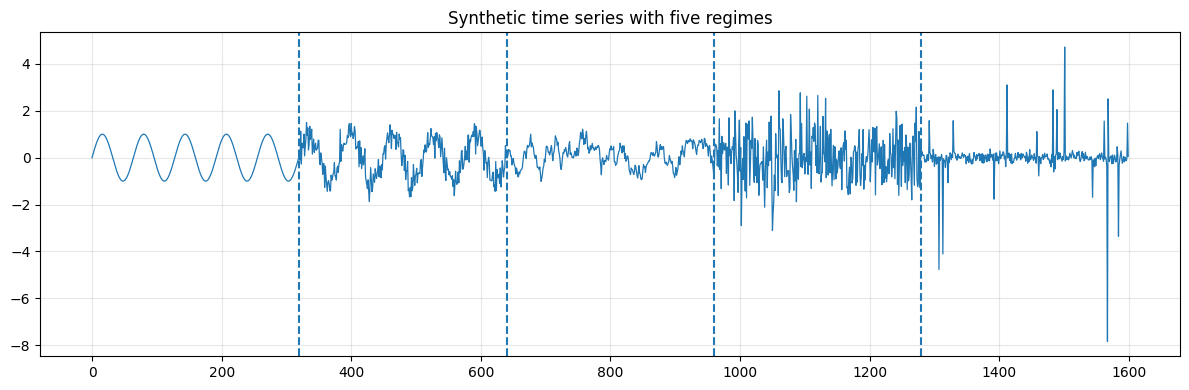

In [3]:
rng = np.random.default_rng(77)

regimes: list[tuple[str, np.ndarray]] = []

t1 = np.linspace(0.0, 10.0 * np.pi, 320)
regimes.append(("regular_sine", np.sin(t1)))

t2 = np.linspace(0.0, 10.0 * np.pi, 320)
regimes.append(("noisy_sine", np.sin(t2) + 0.35 * rng.normal(size=t2.size)))

ar = np.zeros(320)
for i in range(1, ar.size):
    ar[i] = 0.9 * ar[i - 1] + 0.2 * rng.normal()
regimes.append(("ar1_persistent", ar))

regimes.append(("white_noise", rng.normal(size=320)))

spiky = 0.15 * rng.normal(size=320)
spike_idx = rng.choice(np.arange(320), size=20, replace=False)
spiky[spike_idx] += rng.normal(loc=0.0, scale=3.0, size=spike_idx.size)
regimes.append(("spiky_noise", spiky))

series = np.concatenate([values for _, values in regimes])
labels = np.concatenate([[name] * values.size for name, values in regimes])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series, linewidth=0.9)
offset = 0
for name, values in regimes[:-1]:
    offset += len(values)
    ax.axvline(offset, linestyle="--")
ax.set_title("Synthetic time series with five regimes")
ax.grid(alpha=0.3)
plt.tight_layout()

In [4]:
feature_df = rolling_feature_table(series, labels, window=100, step=10)
feature_df.head()

,mean,std,abs_mean,lag1_autocorr,apen,perm_entropy,window_start,window_end,label
0,0.196010,0.664663,0.616113,0.994398,0.260575,0.303347,0,100,regular_sine
1,0.081622,0.712164,0.648131,0.995638,0.274318,0.293976,10,110,regular_sine
2,-0.105735,0.705602,0.645350,0.995488,0.279608,0.295576,20,120,regular_sine
3,-0.198566,0.663099,0.613793,0.994350,0.253320,0.303489,30,130,regular_sine
4,-0.113883,0.702985,0.644335,0.995427,0.273906,0.297025,40,140,regular_sine


In [5]:
baseline_features = ["mean", "std", "abs_mean", "lag1_autocorr"]
entropy_features = baseline_features + ["apen", "perm_entropy"]

train_mask = feature_df["window_end"] <= int(0.7 * len(series))
test_mask = ~train_mask

X_train_base = feature_df.loc[train_mask, baseline_features]
X_test_base = feature_df.loc[test_mask, baseline_features]
X_train_entropy = feature_df.loc[train_mask, entropy_features]
X_test_entropy = feature_df.loc[test_mask, entropy_features]
y_train = feature_df.loc[train_mask, "label"]
y_test = feature_df.loc[test_mask, "label"]

baseline_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=0,
)
baseline_model.fit(X_train_base, y_train)
baseline_pred = baseline_model.predict(X_test_base)

entropy_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=0,
)
entropy_model.fit(X_train_entropy, y_train)
entropy_pred = entropy_model.predict(X_test_entropy)

comparison_table = pd.DataFrame(
    {
        "model": ["baseline", "entropy_enriched"],
        "accuracy": [
            accuracy_score(y_test, baseline_pred),
            accuracy_score(y_test, entropy_pred),
        ],
    }
)
comparison_table

,model,accuracy
0,baseline,0.416667
1,entropy_enriched,0.416667


In [6]:
print("Baseline model report")
print(classification_report(y_test, baseline_pred))

print("\nEntropy-enriched model report")
print(classification_report(y_test, entropy_pred))

Baseline model report
                precision    recall  f1-score   support

ar1_persistent       0.00      0.00      0.00         0
    noisy_sine       0.00      0.00      0.00         0
   spiky_noise       0.00      0.00      0.00        27
   white_noise       0.95      0.95      0.95        21

      accuracy                           0.42        48
     macro avg       0.24      0.24      0.24        48
  weighted avg       0.42      0.42      0.42        48


Entropy-enriched model report
                precision    recall  f1-score   support

ar1_persistent       0.00      0.00      0.00         0
    noisy_sine       0.00      0.00      0.00         0
   spiky_noise       0.00      0.00      0.00        27
   white_noise       0.80      0.95      0.87        21

      accuracy                           0.42        48
     macro avg       0.20      0.24      0.22        48
  weighted avg       0.35      0.42      0.38        48



/opt/pyvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/pyvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/pyvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/pyvenv/lib/python3.13/site-packages/s

In [7]:
importances = pd.Series(entropy_model.feature_importances_, index=entropy_features).sort_values(ascending=False)
importances

std              0.276281
lag1_autocorr    0.190914
abs_mean         0.186232
apen             0.166613
perm_entropy     0.162201
mean             0.017759
dtype: float64

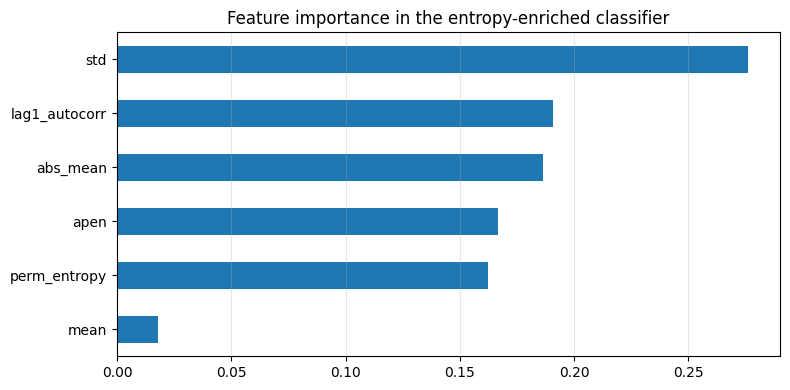

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
importances.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Feature importance in the entropy-enriched classifier")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()

## A simple drift score from rolling ApEn

We can also build a lightweight drift indicator by looking at the change in ApEn itself.
This is not a full production drift detector. It is a compact way to show how entropy can be
used as a regime-transition signal.

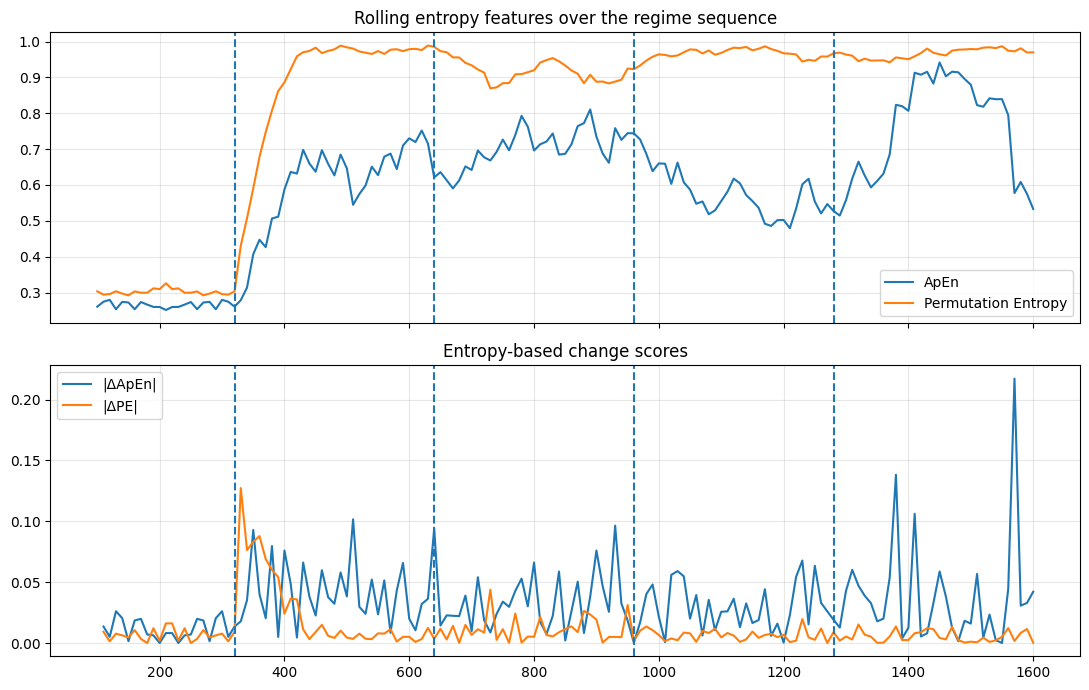

In [9]:
drift_df = feature_df[["window_end", "apen", "perm_entropy", "label"]].copy()
drift_df["apen_change"] = drift_df["apen"].diff().abs()
drift_df["perm_entropy_change"] = drift_df["perm_entropy"].diff().abs()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(drift_df["window_end"], drift_df["apen"], label="ApEn")
axes[0].plot(drift_df["window_end"], drift_df["perm_entropy"], label="Permutation Entropy")
for boundary in np.cumsum([len(values) for _, values in regimes[:-1]]):
    axes[0].axvline(boundary, linestyle="--")
axes[0].legend()
axes[0].set_title("Rolling entropy features over the regime sequence")
axes[0].grid(alpha=0.3)

axes[1].plot(drift_df["window_end"], drift_df["apen_change"], label="|ΔApEn|")
axes[1].plot(drift_df["window_end"], drift_df["perm_entropy_change"], label="|ΔPE|")
for boundary in np.cumsum([len(values) for _, values in regimes[:-1]]):
    axes[1].axvline(boundary, linestyle="--")
axes[1].legend()
axes[1].set_title("Entropy-based change scores")
axes[1].grid(alpha=0.3)

plt.tight_layout()

## Final remarks

This pipeline illustrates a common pattern:

1. compute rolling entropy features,
2. combine them with simpler statistics,
3. use them for classification, drift scoring, or monitoring.

In real systems, the next step would be one of these:

- blocked cross-validation across time,
- online feature computation,
- calibrated thresholds for alerting,
- integration with a drift detector or streaming classifier.